In [1]:
import numpy as np
from scipy.stats import norm

from configurations import apply_general_styles, set_font_sizes, create_fig

apply_general_styles()
set_font_sizes(conf='tight')

In [2]:
def phi(x):
    """Standard normal CDF Phi(x), numerically stable for large |x|."""
    # return 0.5 * (1.0 + np.erf(x / (2.0 ** 0.5)))
    return norm.cdf(x)
def success_prob(snr, L):
    """Probability of correct attention over L-1 positions given SNR."""
    p = phi(snr).clip(min=1e-40, max=1-1e-5) # avoid underflow
    # log_P = -np.log(L-1) + np.log1p(-p**(L-1)) - np.log1p(-p) # log(1 - p^(L-1)) - log(1-p) - log(L-1)
    log_P = (L-1) * np.log(p) # log(p^(L-1)) = (L-1)*log(p)
    return np.exp(log_P)

def delta_L(gamma, V):
    """Induction gain over random guessing."""
    log_V = np.log(float(V))
    log_denom = np.logaddexp(
        0.0,                          # log(exp(0)) = 0
        np.log(float(V - 1)) - gamma   # log((V-1)*exp(-gamma))
    )
    return log_V - log_denom

def pi_theory(L: int, V: int):
    p = 1.0 - 1.0 / V          # (V-1)/V
    if L <= 1:
        return 0.0
    return 1.0 - (V / (L - 1)) * (p - p ** L)


def eff_loss(m1,eta1,m2,eta2,gamma,V,L,epsilon,pi,full_output=False):
    """Effective loss function for gradient descent."""
    log_V = np.log(float(V))
    snr1 , snr2 = m1/eta1, m2/eta2
    pL1 = success_prob(snr1, L)
    pL2 = success_prob(snr2, L)
    deltaL = delta_L(gamma, V)
    eff_loss = log_V - epsilon * pi * pL1 * pL2 * deltaL
    if full_output:
        return {
            'eff_loss': eff_loss,
            'pL1': pL1,
            'pL2': pL2,
            'deltaL': deltaL,
            'snr1': snr1,
            'snr2': snr2
        }
    else:
        return eff_loss

def eff_loss_gradient(m1,eta1,m2,eta2,gamma,V,L,epsilon,pi):
    """Gradient of effective loss w.r.t. m1, eta1, m2, eta2."""
    
    snr1 , snr2 = m1/eta1, m2/eta2
    phi1 = phi(snr1)
    phi2 = phi(snr2)
    deltaL = delta_L(gamma, V)
    p_tilde = 1/(1+np.exp(-gamma)*(V-1))

    prefactor = - epsilon * pi * phi1**(L-2) * phi2**(L-2) 

    dL_dsnr1 = prefactor * np.exp(-snr1**2/2) / np.sqrt(2*np.pi) * phi2 * deltaL
    dL_dsnr2 = prefactor * np.exp(-snr2**2/2) / np.sqrt(2*np.pi) * phi1 * deltaL
    dL_dgamma = prefactor * phi1 * phi2 * (1 - p_tilde)

    dL_dm1 = dL_dsnr1 / eta1
    dL_deta1 = -dL_dsnr1 * m1 / (eta1**2)
    dL_dm2 = dL_dsnr2 / eta2
    dL_deta2 = -dL_dsnr2 * m2 / (eta2**2)

    return np.array([dL_dm1, dL_deta1, dL_dm2, dL_deta2, dL_dgamma])

In [3]:
V , L , K = 16 , 8 , 4
epsilon = K/V
pi = pi_theory(L, V)

lr = 1
nsteps = 10000

results = {
    'step' : [0.0],
    'm1' : [0.2],
    'm2' : [0.2],
    'eta1' : [1.0],
    'eta2' : [0.5],
    'gamma' : [0.0],
    'eff_loss' : []
}

results['eff_loss'].append(eff_loss(results['m1'][-1], results['eta1'][-1], results['m2'][-1], results['eta2'][-1], results['gamma'][-1], V, L, epsilon, pi))

for step in range(nsteps):
    grad = eff_loss_gradient(results['m1'][-1], results['eta1'][-1], results['m2'][-1], results['eta2'][-1], results['gamma'][-1], V, L, epsilon, pi)
    results['step'].append(step*lr)
    results['m1'].append(results['m1'][-1] - lr * grad[0])
    results['eta1'].append(results['eta1'][-1] - lr * grad[1])
    results['m2'].append(results['m2'][-1] - lr * grad[2])
    results['eta2'].append(results['eta2'][-1] - lr * grad[3])
    results['gamma'].append(results['gamma'][-1] - lr * grad[4])
    results['eff_loss'].append(eff_loss(results['m1'][-1], results['eta1'][-1], results['m2'][-1], results['eta2'][-1], results['gamma'][-1], V, L, epsilon, pi))

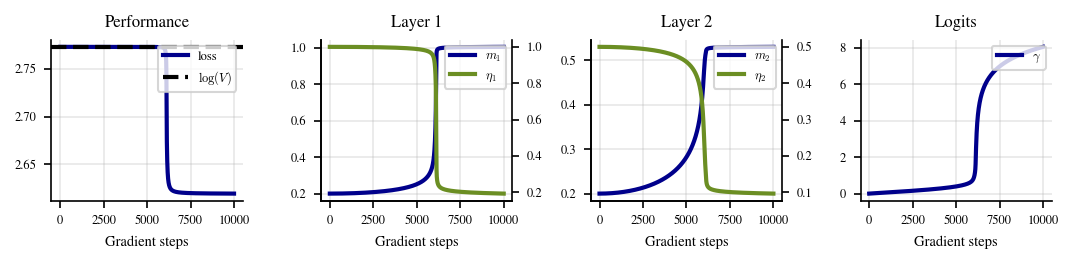

In [5]:
fig, axes = create_fig(ncols=4,size='double',h=0.25,layout='tight')

ax = axes[0]
ax.plot(results['step'], results['eff_loss'], label='loss',color='darkblue')
ax.set_title('Performance',fontsize=8)
ax.axhline(np.log(V), color='k', linestyle='--', label=r'$\log(V)$')
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(results['step'], results['m1'], label=r'$m_1$',color='darkblue')
ax.set_title('Layer 1',fontsize=8)
ax_twin = ax.twinx()
ax_twin.spines['right'].set_visible(True)
ax_twin.plot(results['step'], results['eta1'], label=r'$\eta_1$',color='olivedrab')
# Joint legends to plot them together only on ax to avoid duplicates
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_twin.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc='upper right')

ax = axes[2]
ax.plot(results['step'], results['m2'], label=r'$m_2$',color='darkblue')
ax.set_title('Layer 2',fontsize=8)
ax_twin = ax.twinx()
ax_twin.spines['right'].set_visible(True)
ax_twin.plot(results['step'], results['eta2'], label=r'$\eta_2$',color='olivedrab')
# Joint legends to plot them together only on ax to avoid duplicates
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_twin.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc='upper right')

ax = axes[3]
ax.plot(results['step'], results['gamma'], label=r'$\gamma$',color='darkblue')
ax.set_title('Logits',fontsize=8)
ax.legend(loc='upper right')

for ax in axes:
    ax.set_xlabel('Gradient steps',fontsize=7)
    ax.grid(alpha=0.3)

    

In [ ]:
fig, axes = create_fig(ncols=4,size='double',h=0.45,layout='tight')
        table = _get_plot_data()
        if table is not None:
            matrix_step_idx = input.matrix_step()
            num_matrix_stps = num_matrix_steps()
            last_step = table['step'].max()
            matrix_step = last_step * matrix_step_idx / (num_matrix_stps-1) if num_matrix_stps > 0 else 0

            ax = axes[0]
            ax.plot(table['step'], table['loss'], label='loss',color='darkblue')
            ax.plot(table['step'], table['loss_eff'], label='eff loss',color='orange')
            ax_twin = ax.twinx()
            ax_twin.spines['right'].set_visible(True)
            ax_twin.plot(table['step'], table['top1_accuracy'], label='accuracy',color='olivedrab')
            ax.set_xlabel('Step',fontsize=8)
            ax.set_title('Performance',fontsize=8)
            # Joint legends to plot them together only on ax to avoid duplicates
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax_twin.get_legend_handles_labels()
            ax.legend(h1+h2, l1+l2, loc='upper right')
            # ax.set_ylabel('Loss',color='darkblue')
            # ax_twin.set_ylabel('Accuracy',color='olivedrap')
            ax.axvline(matrix_step, color='peru', linestyle='--', lw=0.5,alpha=0.7)

            ax = axes[1]
            ax.plot(table['step'], table['m1'], label=r'$m_1$',color='darkblue')
            # ax.plot(table['step'], table['center1'], label=r'$c_1$',color='darkred')
            ax_twin = ax.twinx()
            ax_twin.spines['right'].set_visible(True)
            ax_twin.plot(table['step'], table['eta1'], label=r'$\eta_1$',color='olivedrab')
            ax.set_xlabel('Step',fontsize=8)
            ax.set_title('Layer 1',fontsize=8)
            # Joint legends to plot them together only on ax to avoid duplicates
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax_twin.get_legend_handles_labels()
            ax.legend(h1+h2, l1+l2, loc='upper left')
            # ax.set_ylabel(r'$m_1$',color='darkblue')
            # ax_twin.set_ylabel(r'$\eta_1$',color='olivedrap')
            ax.axvline(matrix_step, color='peru', linestyle='--', lw=0.5,alpha=0.7)

            ax = axes[2]
            ax.plot(table['step'], table['m2'], label=r'$m_2$',color='darkblue')
            ax_twin = ax.twinx()
            ax_twin.spines['right'].set_visible(True)
            ax_twin.plot(table['step'], table['eta2'], label=r'$\eta_2$',color='olivedrab')
            ax.set_xlabel('Step',fontsize=8)
            ax.set_title('Layer 2',fontsize=8)
            # Joint legends to plot them together only on ax to avoid duplicates
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax_twin.get_legend_handles_labels()
            ax.legend(h1+h2, l1+l2, loc='upper left')
            # ax.set_ylabel(r'$m_2$',color='darkblue')
            # ax_twin.set_ylabel(r'$\eta_2$',color='olivedrap')
            ax.axvline(matrix_step, color='peru', linestyle='--', lw=0.5,alpha=0.7)

            ax = axes[3]
            ax.plot(table['step'], table['gamma'], label=r'$\gamma$',color='darkblue')
            ax_twin = ax.twinx()
            ax_twin.spines['right'].set_visible(True)
            ax_twin.plot(table['step'], table['eta_gamma'], label=r'$\eta_\gamma$',color='olivedrab')
            ax.set_xlabel('Step',fontsize=8)
            ax.set_title('Readout',fontsize=8)
            # Joint legends to plot them together only on ax to avoid duplicates
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax_twin.get_legend_handles_labels()
            ax.legend(h1+h2, l1+l2, loc='upper left')
            # ax.legend(loc='upper left')
            # ax.set_ylabel(r'$\gamma$')
            ax.axvline(matrix_step, color='peru', linestyle='--', lw=0.5,alpha=0.7)
        return fig